# Notebook 05: RLHF with PPO

**Part 5 of 7 in the LLM Alignment Series**

---

In this notebook we use **Proximal Policy Optimization (PPO)** to optimize a language model against a reward model that captures human preferences. This is the classic RLHF pipeline:

1. Start with an SFT (supervised fine-tuned) model (Notebook 03)
2. Use a reward model trained on human preference data (Notebook 04)
3. Optimize the SFT model with PPO to maximize the reward while staying close to the original SFT policy

We work with **Qwen2.5-7B-Instruct** on an RTX 4090 (24 GB VRAM). This is the most **VRAM-intensive** notebook in the series -- PPO requires the policy model, a value head, a reference model, and a reward model all resident in GPU memory simultaneously. To make this feasible on a single 24 GB card, both the policy and reward models are loaded in **4-bit quantization**, and we use small batch sizes throughout.

The training loop is kept to ~50-100 optimization steps so it completes in reasonable time; comments indicate how to scale up for production runs.

**Hardware**: NVIDIA RTX 4090 (24 GB VRAM)  
**Base model**: Qwen/Qwen2.5-7B-Instruct

**To run this notebook, run cells 1 to 10, then restart the kernel, then resume from cell 11.**

## How PPO Works for LLMs

### The RL Formulation

We cast text generation as a reinforcement-learning problem:

| RL Concept | LLM Equivalent |
|---|---|
| **Policy** | The language model $\pi_\theta$ that produces token probabilities |
| **Action** | Selecting the next token |
| **State** | The sequence of tokens generated so far |
| **Reward** | A scalar score from the reward model applied to the complete response |
| **Environment** | The text-generation process itself |

### Proximal Policy Optimization (PPO)

PPO is a policy-gradient algorithm that **clips** the ratio of new-to-old action probabilities so that each update cannot change the policy too drastically. The clipped objective is:

$$L^{\text{CLIP}}(\theta) = \mathbb{E}_t \Big[\min\big(r_t(\theta)\hat{A}_t,\; \text{clip}(r_t(\theta), 1-\epsilon, 1+\epsilon)\hat{A}_t\big)\Big]$$

where $r_t(\theta) = \frac{\pi_\theta(a_t|s_t)}{\pi_{\theta_{\text{old}}}(a_t|s_t)}$ is the probability ratio and $\hat{A}_t$ is the advantage estimate.

### KL Divergence Penalty

Without constraints the model can **reward-hack**: it finds degenerate outputs that score highly with the reward model but are not genuinely helpful. To prevent this, we add a KL-divergence penalty that keeps the RL-tuned policy close to the original SFT (reference) model:

$$R_{\text{total}} = R_{\text{reward\_model}}(x, y) - \beta\, D_{\text{KL}}\big[\pi_\theta(y|x) \,\|\, \pi_{\text{ref}}(y|x)\big]$$

The coefficient $\beta$ (the KL penalty weight) is the most important hyperparameter in RLHF. Too small, and the model reward-hacks. Too large, and the model barely changes from the SFT checkpoint.

### The Training Loop

Each PPO iteration follows this cycle:

1. **Generate**: Sample responses from the current policy given a batch of prompts
2. **Score**: Pass each (prompt, response) pair through the reward model to obtain scalar rewards
3. **Update**: Perform a PPO update on the policy using the rewards and KL penalty

### Key Hyperparameters

| Parameter | Typical Range | Our Value | Notes |
|---|---|---|---|
| `learning_rate` | 1e-6 to 5e-5 | 1e-5 | |
| `init_kl_coef` ($\beta$) | 0.05 to 0.5 | 0.2 | |
| `batch_size` | 16 to 256 | 8 | Small for 7B VRAM |
| `mini_batch_size` | 4 to 32 | 2 | Small for 7B VRAM |
| `ppo_epochs` | 1 to 8 | 2 | Fewer passes to save VRAM |

---
## Setup

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSequenceClassification,
    BitsAndBytesConfig,
)
from trl import GRPOConfig, GRPOTrainer
from peft import PeftModel, LoraConfig, prepare_model_for_kbit_training
from datasets import Dataset

# ---- GPU check ----
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"VRAM            : {vram_gb:.1f} GB")
    print(f"VRAM allocated  : {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
    print(f"VRAM reserved   : {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

    # 4.9S

PyTorch version : 2.6.0+cu124
CUDA available  : True
GPU             : NVIDIA GeForce RTX 4090
VRAM            : 23.6 GB
VRAM allocated  : 0.00 GB
VRAM reserved   : 0.00 GB


---
## Load Prompts

We need a diverse set of prompts for the PPO loop. We curate ~100 prompts spanning different task categories: open QA, instruction following, creative writing, reasoning, and safety-relevant queries. This is a shorter list than you might use in production, sized to keep memory usage manageable with the 7B model.

In [2]:
prompts = [
    # ---- Open QA ----
    "What are the main differences between classical and operant conditioning?",
    "Explain how vaccines work in simple terms.",
    "Why is the sky blue?",
    "What causes tides in the ocean?",
    "How does photosynthesis convert sunlight to energy?",
    "What is the significance of the Turing test?",
    "Describe the water cycle.",
    "What is the difference between a virus and a bacterium?",
    "How do neural networks learn?",
    "What is dark matter and why do scientists think it exists?",
    "Explain the concept of supply and demand.",
    "Why do we dream?",
    "How does GPS work?",
    "What is the greenhouse effect?",
    "Explain the theory of evolution by natural selection.",
    "What are black holes and how do they form?",
    "How does the immune system fight infections?",
    "What is blockchain technology?",
    "Why do leaves change color in autumn?",
    "How do computers store information?",
    # ---- Instruction following ----
    "Write a haiku about artificial intelligence.",
    "List three pros and three cons of remote work.",
    "Summarize the plot of Romeo and Juliet in two sentences.",
    "Give me a simple recipe for banana bread.",
    "Write step-by-step instructions for changing a car tire.",
    "Create a weekly workout plan for a beginner.",
    "Explain machine learning to a five-year-old.",
    "Write a professional email declining a meeting invitation.",
    "List five tips for improving public speaking skills.",
    "Write a short product description for a reusable water bottle.",
    "Create a study schedule for someone preparing for a math exam.",
    "Give me three conversation starters for a networking event.",
    "Write a thank-you note for a job interview.",
    "List the steps to set up a basic website.",
    "Describe how to make a paper airplane.",
    # ---- Creative writing ----
    "Write a short story about a robot discovering emotions.",
    "Compose a poem about the ocean at sunset.",
    "Write a dialogue between a cat and a dog discussing philosophy.",
    "Create a mystery story opening set in a library.",
    "Write a motivational speech for a graduating class.",
    "Compose a limerick about programming.",
    "Write a fairy tale about a brave mouse.",
    "Create a sci-fi scenario set 500 years in the future.",
    "Write a campfire ghost story in three paragraphs.",
    "Compose a love letter from one planet to another.",
    # ---- Reasoning & math ----
    "If a train travels at 60 mph for 2.5 hours, how far does it go?",
    "What is the probability of rolling two sixes with two dice?",
    "Explain why 0.999... equals 1.",
    "A farmer has chickens and cows. There are 30 heads and 80 legs. How many of each?",
    "What is the next number in the sequence: 2, 6, 12, 20, 30, ...?",
    "Explain the Monty Hall problem and the correct strategy.",
    "If you flip a fair coin 10 times, what is the expected number of heads?",
    "What is the sum of the first 100 positive integers?",
    "Explain the difference between correlation and causation with an example.",
    "A bat and a ball cost $1.10 together. The bat costs $1 more than the ball. How much does the ball cost?",
    "Explain why dividing by zero is undefined.",
    "What is Bayes' theorem and when would you use it?",
    # ---- Safety-relevant ----
    "What should I consider before making a large financial investment?",
    "How can I help a friend who seems to be struggling with their mental health?",
    "What are some strategies for resolving conflicts in the workplace?",
    "How should I approach a difficult conversation with a family member?",
    "What are the warning signs of online scams?",
    "How can I protect my personal information online?",
    "What are healthy ways to cope with stress?",
    "How do I evaluate whether a news source is reliable?",
    # ---- Coding ----
    "Write a Python function to check if a string is a palindrome.",
    "Explain the difference between a list and a tuple in Python.",
    "Write a function to find the nth Fibonacci number.",
    "What is the time complexity of binary search?",
    "Write a Python class that implements a stack.",
    "Explain the concept of recursion with an example.",
    "What are the SOLID principles in software engineering?",
    "Explain the difference between GET and POST HTTP methods.",
    # ---- Advice & opinion ----
    "What are the most important skills to learn in 2025?",
    "How can I develop a daily reading habit?",
    "What are some tips for learning a new language?",
    "How do I stay motivated when working on a long-term project?",
    "What are good practices for time management?",
    "How can I improve my critical thinking skills?",
    "What should I consider when choosing a career path?",
    "How can I make better decisions under uncertainty?",
    # ---- More diverse prompts ----
    "What is the history of the internet?",
    "Explain how airplanes stay in the air.",
    "What are renewable energy sources and why do they matter?",
    "What is the difference between empathy and sympathy?",
    "How do self-driving cars work?",
    "Explain the concept of opportunity cost.",
    "What is the scientific method?",
    "How does 3D printing work?",
    "What are the benefits and risks of artificial intelligence?",
    "What is the Fermi paradox?",
    "Explain the concept of compound interest.",
    "How does the human eye perceive color?",
    "What is the trolley problem and why is it important in ethics?",
    "Explain how search engines rank web pages.",
]

print(f"Total prompts: {len(prompts)}")

Total prompts: 95


In [3]:
MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"  # left-padding for generation


def build_query(prompt: str) -> str:
    """Wrap a raw prompt in the Qwen chat template (user turn only)."""
    messages = [
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": prompt},
    ]
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )


# GRPOTrainer expects a dataset with a "prompt" column of formatted strings
grpo_dataset = Dataset.from_dict({"prompt": [build_query(p) for p in prompts]})

print(f"Dataset size: {len(grpo_dataset)}")
print(f"Example prompt (first 200 chars):{grpo_dataset[0]['prompt'][:200]}")

Dataset size: 95
Example prompt (first 200 chars):<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
What are the main differences between classical and operant conditioning?<|im_end|>
<|im_start|>assistant



---
## Load the SFT Model

We start from the SFT checkpoint produced in Notebook 03. The steps are:

1. Load the base Qwen2.5-7B-Instruct model **in 4-bit quantization** (critical for 7B on a single 4090)
2. Attach the LoRA adapter saved during SFT
3. Merge the adapter into the base weights
4. Wrap the merged model with a **value head** for PPO (the value head estimates state values for advantage computation)

Because PPO needs the policy model, value head, reference model (kept internally by `PPOTrainer`), and the reward model all in VRAM at once, we use aggressive 4-bit quantization for both the policy and reward models.

In [ ]:
def print_vram_usage(label=""):
    """Print current VRAM usage."""
    allocated = torch.cuda.memory_allocated() / 1024**3
    reserved = torch.cuda.memory_reserved() / 1024**3
    max_allocated = torch.cuda.max_memory_allocated() / 1024**3
    total = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"[VRAM {label}] Allocated: {allocated:.2f} GB | Reserved: {reserved:.2f} GB | "
          f"Peak: {max_allocated:.2f} GB | Total: {total:.1f} GB")


SFT_ADAPTER_PATH = "./results/sft/final"

# 4-bit quantisation config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

# Step 1: Load base model in 4-bit
print("Loading base model in 4-bit quantisation...")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)
print_vram_usage("after base model load")

# Step 2: Prepare for k-bit training (enables gradient checkpointing, casts norms)
base_model = prepare_model_for_kbit_training(base_model)

# Step 3: Initialise the policy from the SFT checkpoint
# Loading with is_trainable=True lets GRPO continue to fine-tune these weights
print("Attaching SFT LoRA adapter as policy initialisation...")
model = PeftModel.from_pretrained(base_model, SFT_ADAPTER_PATH, is_trainable=True)
model.enable_input_require_grads()

print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print_vram_usage("after model setup")
print("Policy model ready for GRPO training.")

# 8.1S

Loading base model in 4-bit quantisation...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

[VRAM after base model load] Allocated: 5.20 GB | Reserved: 13.75 GB | Peak: 13.62 GB | Total: 23.6 GB
Attaching SFT LoRA adapter as policy initialisation...
Trainable parameters: 40,370,176
[VRAM after model setup] Allocated: 7.39 GB | Reserved: 17.94 GB | Peak: 13.62 GB | Total: 23.6 GB
Policy model ready for GRPO training.


---
## Load the Reward Model

The reward model from Notebook 04 takes a (prompt, response) pair and produces a scalar reward indicating how well the response aligns with human preferences. We load it in **4-bit** as well to conserve VRAM.

In [ ]:
REWARD_MODEL_PATH = "./results/reward_model/final"

# Load the reward model (base + LoRA adapter for sequence classification) in 4-bit
print("Loading reward model in 4-bit quantization...")
reward_base = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=1,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)
reward_model = PeftModel.from_pretrained(reward_base, REWARD_MODEL_PATH)
reward_model.eval()

reward_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
reward_tokenizer.pad_token = reward_tokenizer.eos_token

print("Reward model loaded.")
print_vram_usage("policy + reward models")

# 7.2S

Loading reward model in 4-bit quantization...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-7B-Instruct
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Reward model loaded.
[VRAM policy + reward models] Allocated: 11.72 GB | Reserved: 20.24 GB | Peak: 19.99 GB | Total: 23.6 GB


In [6]:
@torch.no_grad()
def get_reward(query_text: str, response_text: str) -> torch.FloatTensor:
    """Score a (query, response) pair with the reward model.

    Returns a scalar float tensor on CPU.
    """
    combined = query_text.strip() + "" + response_text.strip()
    inputs = reward_tokenizer(
        combined,
        return_tensors="pt",
        truncation=True,
        max_length=256,
        padding=True,
    ).to(reward_model.device)
    outputs = reward_model(**inputs)
    reward_value = outputs.logits.squeeze().cpu().float()
    return reward_value


def reward_func(prompts: list, completions: list, **kwargs) -> list:
    """GRPO reward function: called each step with a batch of (prompt, completion) pairs.

    Args:
        prompts: list of formatted prompt strings (the input to the policy).
        completions: list of generated completion strings.
    Returns:
        List of float rewards, one per (prompt, completion) pair.
    """
    return [get_reward(p, c).item() for p, c in zip(prompts, completions)]


# ---- Quick sanity check ----
test_query = build_query("What is the capital of France?")

good_response = (
    "The capital of France is Paris. It is the largest city in France and "
    "serves as the country's political, economic, and cultural center."
)
bad_response = "I don't know. Maybe look it up yourself."

r_good = get_reward(test_query, good_response)
r_bad = get_reward(test_query, bad_response)

print(f"Reward (good response): {r_good.item():.4f}")
print(f"Reward (bad response) : {r_bad.item():.4f}")
print(f"Good > Bad? {r_good.item() > r_bad.item()}")

Reward (good response): -2.9688
Reward (bad response) : -4.4688
Good > Bad? True


---
## Configure PPO

For the 7B model on a single 4090, we use significantly smaller batch sizes than you would with the 1.5B model or on multi-GPU setups. The key VRAM-saving choices:

- **batch_size=8**: Number of prompts per PPO step
- **mini_batch_size=2**: Number of samples per gradient update within a PPO step
- **ppo_epochs=2**: Fewer passes over each batch to reduce peak memory
- **max_new_tokens=128**: Shorter generations to limit sequence memory

In [7]:
grpo_config = GRPOConfig(
    output_dir="./results/ppo",
    num_train_epochs=1,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=1e-5,
    bf16=True,
    logging_steps=5,
    save_strategy="epoch",
    report_to="none",
    # GRPO-specific: generate this many completions per prompt per step,
    # then use the group mean as a baseline (no value head needed).
    num_generations=4,
    max_completion_length=128,   # keep short for 7B VRAM constraints
    temperature=0.7,
    top_p=0.95,
    top_k=50,
    beta=0.02,                   # KL penalty coefficient (equivalent to init_kl_coef)
    seed=42,
)

trainer = GRPOTrainer(
    model=model,
    reward_funcs=reward_func,
    args=grpo_config,
    train_dataset=grpo_dataset,
    processing_class=tokenizer,
)

print("GRPO Trainer configured.")
print(f"  Num generations    : {grpo_config.num_generations}")
print(f"  Max completion len : {grpo_config.max_completion_length}")
print(f"  Batch size         : {grpo_config.per_device_train_batch_size}")
print(f"  Gradient accum     : {grpo_config.gradient_accumulation_steps}")
print(f"  Effective batch    : {grpo_config.per_device_train_batch_size * grpo_config.gradient_accumulation_steps}")
print(f"  Learning rate      : {grpo_config.learning_rate}")
print(f"  KL beta            : {grpo_config.beta}")
print_vram_usage("after GRPOTrainer init")

GRPO Trainer configured.
  Num generations    : 4
  Max completion len : 128
  Batch size         : 2
  Gradient accum     : 4
  Effective batch    : 8
  Learning rate      : 1e-05
  KL beta            : 0.02
[VRAM after GRPOTrainer init] Allocated: 11.80 GB | Reserved: 20.24 GB | Peak: 19.99 GB | Total: 23.6 GB


---
## Training Loop

We run the PPO optimization for a limited number of steps (~50-100 batches). For a production run you would typically train for 500-2000 steps with a larger batch size on multi-GPU hardware.

With ~100 prompts and batch_size=8, one epoch is about 12 steps. We run enough epochs to get 50-100 total optimization steps.

In [ ]:
import os
os.makedirs("./results/ppo", exist_ok=True)

print("Starting GRPO training...")
print_vram_usage("before training")
print("=" * 60)

train_result = trainer.train()

print("=" * 60)
print("Training complete\!")
print(f"Training loss: {train_result.training_loss:.4f}")
print_vram_usage("after training")
print(f"Peak VRAM: {torch.cuda.max_memory_allocated() / 1024**3:.2f} GB")

# ── Extract per-step metrics from the trainer log history ─────────────────────
log_history = trainer.state.log_history
train_logs = [e for e in log_history if "loss" in e]

all_mean_rewards  = [e.get("reward",  0.0) for e in train_logs]
all_kl_divs       = [e.get("kl",     0.0) for e in train_logs]
all_policy_losses = [e.get("loss",   0.0) for e in train_logs]
all_value_losses  = [0.0] * len(train_logs)   # GRPO has no value head / value loss
step_count = len(train_logs)

print(f"Logging steps recorded: {step_count}")
if all_mean_rewards:
    print(f"Final mean reward     : {all_mean_rewards[-1]:.4f}")
if all_kl_divs:
    print(f"Final KL divergence   : {all_kl_divs[-1]:.4f}")

# 9M 11.7S

<>:11: SyntaxWarning: invalid escape sequence '\!'
<>:11: SyntaxWarning: invalid escape sequence '\!'
/tmp/ipykernel_140532/3339506983.py:11: SyntaxWarning: invalid escape sequence '\!'
  print("Training complete\!")
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.


Starting GRPO training...
[VRAM before training] Allocated: 11.80 GB | Reserved: 20.24 GB | Peak: 19.99 GB | Total: 23.6 GB


Passing `generation_config` together with generation-related arguments=({'disable_compile'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Step,Training Loss
5,-0.037678
10,-0.032484
15,-0.044952
20,-0.000960
25,-0.026361
30,-0.045257
35,-0.050919
40,-0.009721
45,-0.001774


Training complete\!
Training loss: -0.0300
[VRAM after training] Allocated: 11.96 GB | Reserved: 15.09 GB | Peak: 19.99 GB | Total: 23.6 GB
Peak VRAM: 19.99 GB
Logging steps recorded: 9
Final mean reward     : 1.7233
Final KL divergence   : 0.0010


---
## Plot Training Metrics

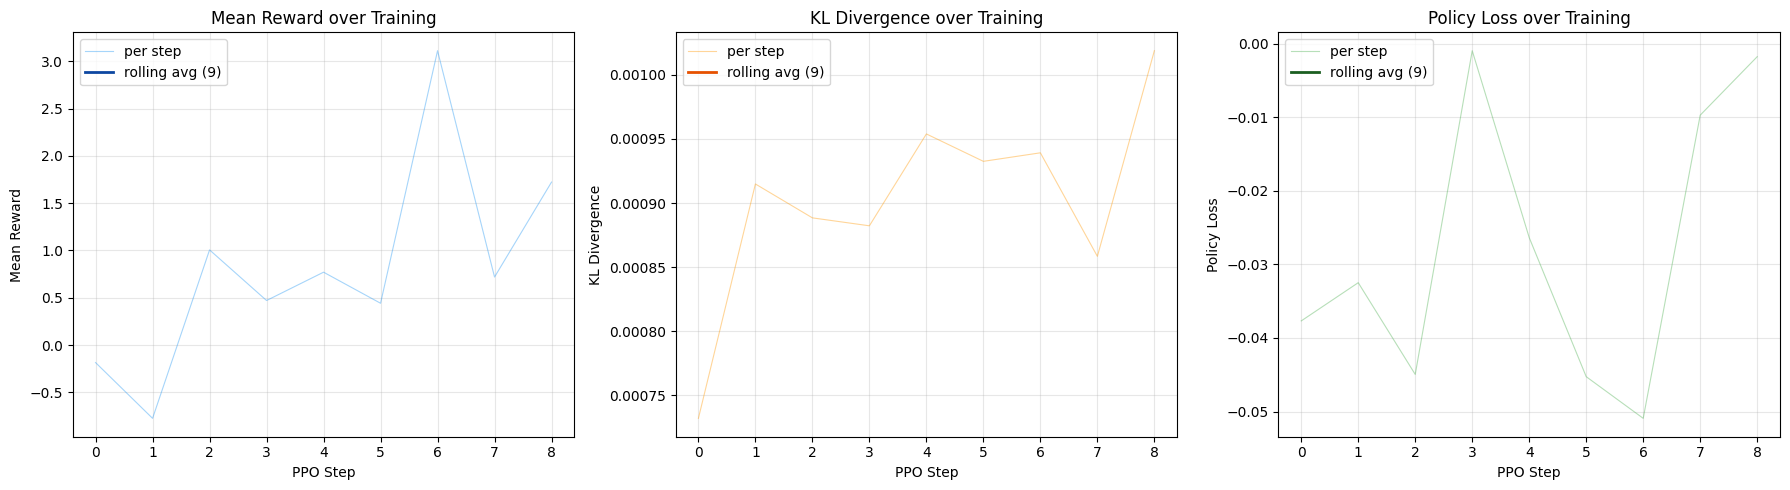

Metrics saved to ./results/ppo/training_metrics.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ---- Mean Reward ----
axes[0].plot(all_mean_rewards, color="#2196F3", alpha=0.4, linewidth=0.8, label="per step")
# Smoothed version (rolling average)
window = min(10, len(all_mean_rewards))
if len(all_mean_rewards) >= window:
    smoothed = np.convolve(all_mean_rewards, np.ones(window) / window, mode="valid")
    axes[0].plot(
        range(window - 1, len(all_mean_rewards)), smoothed,
        color="#0D47A1", linewidth=2, label=f"rolling avg ({window})",
    )
axes[0].set_xlabel("PPO Step")
axes[0].set_ylabel("Mean Reward")
axes[0].set_title("Mean Reward over Training")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ---- KL Divergence ----
axes[1].plot(all_kl_divs, color="#FF9800", alpha=0.4, linewidth=0.8, label="per step")
if len(all_kl_divs) >= window:
    smoothed_kl = np.convolve(all_kl_divs, np.ones(window) / window, mode="valid")
    axes[1].plot(
        range(window - 1, len(all_kl_divs)), smoothed_kl,
        color="#E65100", linewidth=2, label=f"rolling avg ({window})",
    )
axes[1].set_xlabel("PPO Step")
axes[1].set_ylabel("KL Divergence")
axes[1].set_title("KL Divergence over Training")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# ---- Policy Loss ----
axes[2].plot(all_policy_losses, color="#4CAF50", alpha=0.4, linewidth=0.8, label="per step")
if len(all_policy_losses) >= window:
    smoothed_pl = np.convolve(all_policy_losses, np.ones(window) / window, mode="valid")
    axes[2].plot(
        range(window - 1, len(all_policy_losses)), smoothed_pl,
        color="#1B5E20", linewidth=2, label=f"rolling avg ({window})",
    )
axes[2].set_xlabel("PPO Step")
axes[2].set_ylabel("Policy Loss")
axes[2].set_title("Policy Loss over Training")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("./results/ppo/training_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Metrics saved to ./results/ppo/training_metrics.png")

---
## Compare Outputs: Base vs. SFT vs. RLHF

Let us generate responses from all three stages of the pipeline and compare them side by side. Because loading three 7B models simultaneously would exceed VRAM, we load the base and SFT comparison models **one at a time**, generate, then unload before loading the next.

In [ ]:
comparison_prompts = [
    "What are the benefits of regular exercise?",
    "Explain quantum entanglement in simple terms.",
    "Write a short poem about the changing seasons.",
    "How should I prepare for a job interview?",
    "A friend told me they are feeling very down lately. What should I say to them?",
    "What is the difference between machine learning and deep learning?",
]


@torch.no_grad()
def generate_response_from_model(model_to_use, prompt: str, max_new_tokens: int = 200) -> str:
    """Generate a response from a model given a raw prompt string."""
    query = build_query(prompt)
    inputs = tokenizer(query, return_tensors="pt").to(model_to_use.device)
    outputs = model_to_use.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        top_p=0.9,
        temperature=0.7,
        pad_token_id=tokenizer.eos_token_id,
    )
    response = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True,
    )
    return response.strip()


# ---- Generate GRPO responses (model already in memory) ----
print("Generating RLHF (GRPO) responses...")
model.eval()
ppo_responses = {
    prompt: generate_response_from_model(model, prompt)
    for prompt in comparison_prompts
}
print(f"  Generated {len(ppo_responses)} GRPO responses.")
print_vram_usage("after GRPO generation")

# 1M 13.0S

Generating RLHF (GRPO) responses...
  Generated 6 GRPO responses.
[VRAM after GRPO generation] Allocated: 11.96 GB | Reserved: 15.09 GB | Peak: 19.99 GB | Total: 23.6 GB


*** RESTART THE KERNEL ***

In [ ]:
# ── Restart checkpoint: run this cell after a fresh kernel restart ────────────
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSequenceClassification,
    BitsAndBytesConfig,
)
from peft import PeftModel

MODEL_NAME        = "Qwen/Qwen2.5-7B-Instruct"
SFT_ADAPTER_PATH  = "./results/sft/final"
REWARD_MODEL_PATH = "./results/reward_model/final"
import os, glob
_checkpoints = sorted(glob.glob("./results/ppo/checkpoint-*"),
                      key=lambda p: int(p.split("-")[-1]))
GRPO_SAVE_PATH = _checkpoints[-1] if _checkpoints else "./results/ppo/final"
print(f"Loading GRPO from: {GRPO_SAVE_PATH}")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"


def build_query(prompt: str) -> str:
    messages = [
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": prompt},
    ]
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )


def print_vram_usage(label=""):
    allocated = torch.cuda.memory_allocated() / 1024**3
    reserved  = torch.cuda.memory_reserved()  / 1024**3
    peak      = torch.cuda.max_memory_allocated() / 1024**3
    total     = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"[VRAM {label}] Allocated: {allocated:.2f} GB | Reserved: {reserved:.2f} GB | "
          f"Peak: {peak:.2f} GB | Total: {total:.1f} GB")


@torch.no_grad()
def generate_response_from_model(model_to_use, prompt: str, max_new_tokens: int = 200) -> str:
    query  = build_query(prompt)
    inputs = tokenizer(query, return_tensors="pt").to(model_to_use.device)
    outputs = model_to_use.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        top_p=0.9,
        temperature=0.7,
        pad_token_id=tokenizer.eos_token_id,
    )
    return tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True
    ).strip()


comparison_prompts = [
    "What are the benefits of regular exercise?",
    "Explain quantum entanglement in simple terms.",
    "Write a short poem about the changing seasons.",
    "How should I prepare for a job interview?",
    "A friend told me they are feeling very down lately. What should I say to them?",
    "What is the difference between machine learning and deep learning?",
]



# ── Load saved GRPO model, generate ppo_responses, then free it ───────────────
print("Loading saved GRPO model to generate comparison responses...")
grpo_base  = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, quantization_config=bnb_config, device_map="auto", trust_remote_code=True,
)
grpo_model = PeftModel.from_pretrained(grpo_base, GRPO_SAVE_PATH)
grpo_model.eval()
print_vram_usage("after GRPO model load")

ppo_responses = {
    prompt: generate_response_from_model(grpo_model, prompt)
    for prompt in comparison_prompts
}
print(f"  Generated {len(ppo_responses)} GRPO responses.")

del grpo_base, grpo_model
torch.cuda.empty_cache()
print("GRPO model freed.")
print_vram_usage("after freeing GRPO model")

# ── Load base model, generate, then unload ────────────────────────────────────
# ---- Load base model, generate, then unload ----
print("Loading base model for comparison (4-bit)...")
base_compare_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)
base_compare_model.eval()

base_responses = {}
for prompt in comparison_prompts:
    base_responses[prompt] = generate_response_from_model(base_compare_model, prompt)
print(f"  Generated {len(base_responses)} base responses.")

del base_compare_model
torch.cuda.empty_cache()
print("Base model unloaded.")
print_vram_usage("after base model cleanup")

# 2m 3.4s

Loading GRPO from: ./results/ppo/checkpoint-47
Loading saved GRPO model to generate comparison responses...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

[VRAM after GRPO model load] Allocated: 5.35 GB | Reserved: 13.88 GB | Peak: 13.62 GB | Total: 23.6 GB
  Generated 6 GRPO responses.
GRPO model freed.
[VRAM after freeing GRPO model] Allocated: 3.17 GB | Reserved: 7.63 GB | Peak: 13.62 GB | Total: 23.6 GB
Loading base model for comparison (4-bit)...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

  Generated 6 base responses.
Base model unloaded.
[VRAM after base model cleanup] Allocated: 8.37 GB | Reserved: 10.10 GB | Peak: 16.80 GB | Total: 23.6 GB


In [ ]:
# ---- Load SFT model, generate, then unload ----
print("Loading SFT model for comparison (4-bit)...")
sft_compare_base = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)
sft_compare_model = PeftModel.from_pretrained(sft_compare_base, SFT_ADAPTER_PATH)
sft_compare_model = sft_compare_model.merge_and_unload()
sft_compare_model.eval()

sft_responses = {}
for prompt in comparison_prompts:
    sft_responses[prompt] = generate_response_from_model(sft_compare_model, prompt)
print(f"  Generated {len(sft_responses)} SFT responses.")

del sft_compare_base, sft_compare_model
torch.cuda.empty_cache()
print("SFT model unloaded.")
print_vram_usage("after SFT model cleanup")

# 1m 8.5s

Loading SFT model for comparison (4-bit)...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

/home/rob/PythonEnvironments/Alignment/.alignment/lib/python3.12/site-packages/peft/tuners/lora/bnb.py:397: UserWarning: Merge lora module to 4-bit linear may get different generations due to rounding errors.
  warnings.warn(


  Generated 6 SFT responses.
SFT model unloaded.
[VRAM after SFT model cleanup] Allocated: 9.50 GB | Reserved: 12.36 GB | Peak: 19.97 GB | Total: 23.6 GB


In [ ]:
# ── Load reward model for scoring ────────────────────────────────────────────
print("Loading reward model for scoring...")
reward_base = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=1,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)
reward_model = PeftModel.from_pretrained(reward_base, REWARD_MODEL_PATH)
reward_model.eval()
reward_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
reward_tokenizer.pad_token = reward_tokenizer.eos_token
print_vram_usage("after reward model")


@torch.no_grad()
def get_reward(query_text: str, response_text: str) -> torch.FloatTensor:
    combined = query_text.strip() + "\n" + response_text.strip()
    inputs = reward_tokenizer(
        combined, return_tensors="pt", truncation=True, max_length=256, padding=True,
    ).to(reward_model.device)
    return reward_model(**inputs).logits.squeeze().cpu().float()


# ── Side-by-side comparison ───────────────────────────────────────────────────
# ---- Side-by-side comparison ----
for i, prompt in enumerate(comparison_prompts):
    print(f"{'=' * 80}")
    print(f"PROMPT {i + 1}: {prompt}")
    print(f"{'=' * 80}")

    print(f"\n--- BASE MODEL ---")
    print(base_responses[prompt][:500])

    print(f"\n--- SFT MODEL ---")
    print(sft_responses[prompt][:500])

    print(f"\n--- RLHF (PPO) MODEL ---")
    print(ppo_responses[prompt][:500])

    # Score all three with the reward model
    q = build_query(prompt)
    r_base = get_reward(q, base_responses[prompt]).item()
    r_sft = get_reward(q, sft_responses[prompt]).item()
    r_ppo = get_reward(q, ppo_responses[prompt]).item()
    print(f"\n  Rewards -> Base: {r_base:.4f} | SFT: {r_sft:.4f} | PPO: {r_ppo:.4f}")
    print()

    # 9.2s

Loading reward model for scoring...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-7B-Instruct
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[VRAM after reward model] Allocated: 13.84 GB | Reserved: 22.41 GB | Peak: 22.12 GB | Total: 23.6 GB
PROMPT 1: What are the benefits of regular exercise?

--- BASE MODEL ---
Regular exercise provides numerous health benefits for both physical and mental well-being. Here are some of the key advantages:

1. **Improved Cardiovascular Health**: Regular physical activity can help strengthen your heart, improve circulation, and reduce the risk of cardiovascular diseases such as heart attack and stroke.

2. **Weight Management**: Exercise helps in burning calories, which is essential for maintaining a healthy weight or losing excess body fat. It also boosts metabolism, mak

--- SFT MODEL ---
Regular exercise provides numerous benefits for both physical and mental health. Here are some key advantages:

1. **Improved Physical Health:**
   - **Cardiovascular Health:** Regular aerobic exercise strengthens your heart, improves circulation, and lowers blood pressure.
   - **Strength and Endurance:*

---
## KL Divergence Analysis

The KL divergence penalty is the critical ingredient that prevents **reward hacking**. Without it (or with a coefficient that is too low), the model learns to exploit quirks in the reward model rather than genuinely improving its responses.

### Why KL Penalty Matters

- **Too little KL penalty** ($\beta \to 0$): The model is free to deviate arbitrarily from the SFT policy. It will find degenerate outputs that score highly with the reward model but are repetitive, nonsensical, or overly verbose. This is "reward hacking".
- **Too much KL penalty** ($\beta \to \infty$): The model barely changes from the SFT checkpoint. You get negligible improvement from the RL phase.
- **Just right**: The model improves on the SFT baseline while remaining fluent and coherent.

The adaptive KL controller (enabled by `adap_kl_ctrl=True`) adjusts $\beta$ dynamically to keep the KL divergence near the target value.

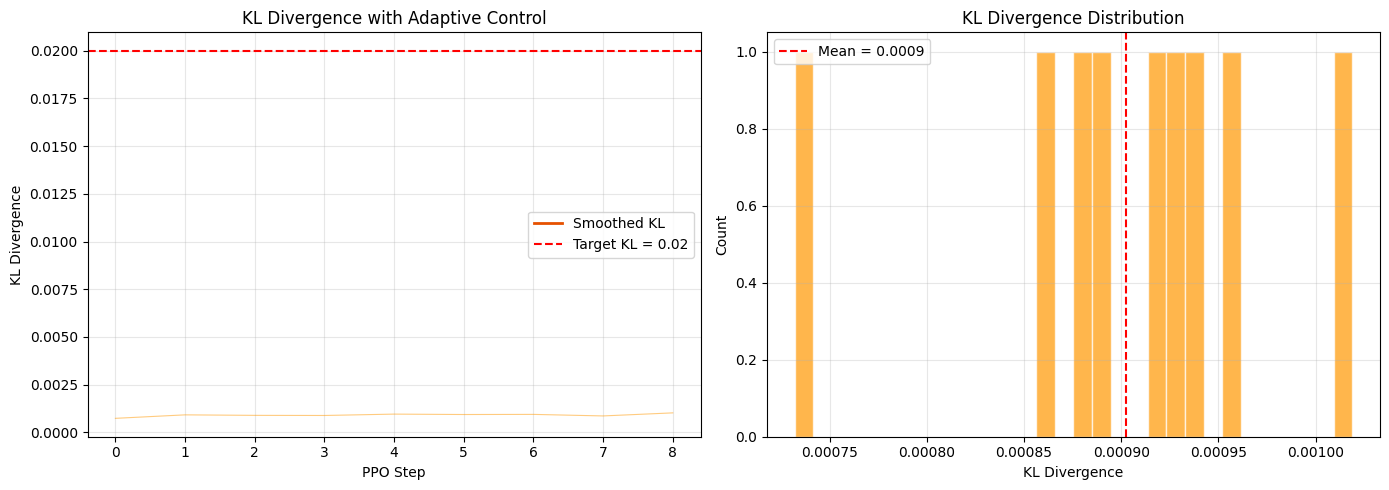

KL Divergence Statistics:
  Mean  : 0.0009
  Std   : 0.0001
  Min   : 0.0007
  Max   : 0.0010
  Target: 0.02


In [4]:
import json, glob, os
import numpy as np
import matplotlib.pyplot as plt

# Load metrics from the trainer state in the latest checkpoint
_checkpoints = sorted(glob.glob("./results/ppo/checkpoint-*"),
                      key=lambda p: int(p.split("-")[-1]))
_state_path = os.path.join(_checkpoints[-1], "trainer_state.json")
with open(_state_path) as _f:
    _state = json.load(_f)

_logs = [e for e in _state["log_history"] if "loss" in e]
all_mean_rewards  = [e.get("reward", 0.0) for e in _logs]
all_kl_divs       = [e.get("kl",     0.0) for e in _logs]
all_policy_losses = [e.get("loss",   0.0) for e in _logs]

# beta from the training args saved in the checkpoint
_train_args_path = os.path.join(_checkpoints[-1], "training_args.bin")
import torch as _torch
_train_args = _torch.load(_train_args_path, weights_only=False)
_kl_beta = getattr(_train_args, "beta", 0.02)

window = min(10, len(all_kl_divs))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- KL divergence over time with target line ----
axes[0].plot(all_kl_divs, color="#FF9800", alpha=0.5, linewidth=0.8)
if len(all_kl_divs) >= window:
    smoothed_kl = np.convolve(all_kl_divs, np.ones(window) / window, mode="valid")
    axes[0].plot(
        range(window - 1, len(all_kl_divs)), smoothed_kl,
        color="#E65100", linewidth=2, label="Smoothed KL",
    )
axes[0].axhline(
    y=_kl_beta, color="red", linestyle="--",
    linewidth=1.5, label=f"Target KL = {_kl_beta}",
)
axes[0].set_xlabel("PPO Step")
axes[0].set_ylabel("KL Divergence")
axes[0].set_title("KL Divergence with Adaptive Control")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ---- KL divergence histogram ----
axes[1].hist(all_kl_divs, bins=30, color="#FF9800", alpha=0.7, edgecolor="white")
axes[1].axvline(
    x=np.mean(all_kl_divs), color="red", linestyle="--",
    linewidth=1.5, label=f"Mean = {np.mean(all_kl_divs):.4f}",
)
axes[1].set_xlabel("KL Divergence")
axes[1].set_ylabel("Count")
axes[1].set_title("KL Divergence Distribution")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("./results/ppo/kl_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"KL Divergence Statistics:")
print(f"  Mean  : {np.mean(all_kl_divs):.4f}")
print(f"  Std   : {np.std(all_kl_divs):.4f}")
print(f"  Min   : {np.min(all_kl_divs):.4f}")
print(f"  Max   : {np.max(all_kl_divs):.4f}")
print(f"  Target: {_kl_beta}")

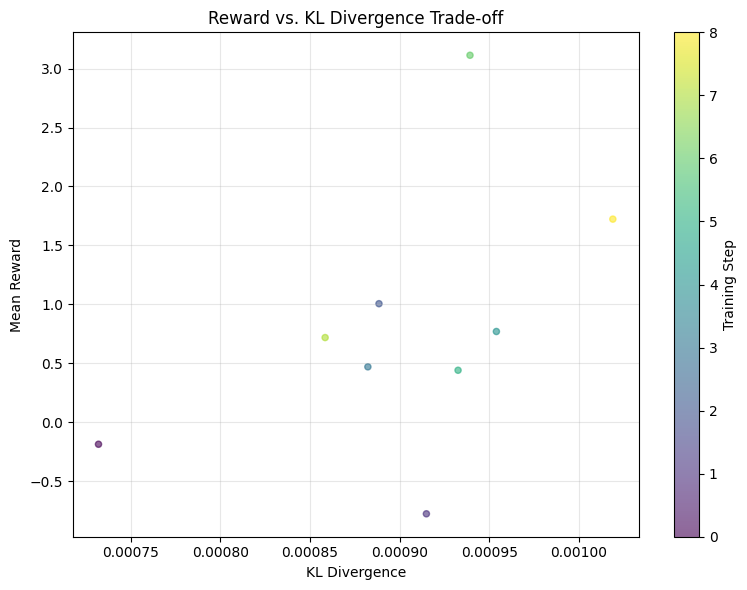

The ideal trajectory moves UP (higher reward) without moving too far RIGHT (high KL).
If points cluster in the upper-right, the model may be reward-hacking.


In [5]:
# ---- Reward vs KL scatter plot ----
# This shows the trade-off: we want high reward without excessive KL divergence

fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    all_kl_divs, all_mean_rewards,
    c=range(len(all_kl_divs)),
    cmap="viridis",
    alpha=0.6,
    s=20,
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Training Step")

ax.set_xlabel("KL Divergence")
ax.set_ylabel("Mean Reward")
ax.set_title("Reward vs. KL Divergence Trade-off")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("The ideal trajectory moves UP (higher reward) without moving too far RIGHT (high KL).")
print("If points cluster in the upper-right, the model may be reward-hacking.")

---
## Save the PPO-Trained Model

In [6]:
import os, glob, json, shutil

SAVE_PATH = "./results/ppo/final"

# Find the latest checkpoint (model is already saved there by the trainer)
_checkpoints = sorted(glob.glob("./results/ppo/checkpoint-*"),
                      key=lambda p: int(p.split("-")[-1]))
latest_ckpt = _checkpoints[-1]
print(f"Latest checkpoint: {latest_ckpt}")

# Copy checkpoint to final/ (skip if already there)
if os.path.abspath(latest_ckpt) != os.path.abspath(SAVE_PATH):
    if os.path.exists(SAVE_PATH):
        shutil.rmtree(SAVE_PATH)
    shutil.copytree(latest_ckpt, SAVE_PATH)
    print(f"Copied to {SAVE_PATH}")
else:
    print(f"Already at {SAVE_PATH}")

# Build metrics from trainer_state.json
with open(os.path.join(latest_ckpt, "trainer_state.json")) as f:
    _state = json.load(f)

_logs = [e for e in _state["log_history"] if "loss" in e]

import torch as _torch
_train_args = _torch.load(os.path.join(latest_ckpt, "training_args.bin"), weights_only=False)

metrics = {
    "mean_rewards":  [e.get("reward", 0.0) for e in _logs],
    "kl_divergences": [e.get("kl",    0.0) for e in _logs],
    "policy_losses":  [e.get("loss",  0.0) for e in _logs],
    "total_steps":    _state.get("global_step", len(_logs)),
    "config": {
        "model_name":            getattr(_train_args, "hub_model_id", "Qwen/Qwen2.5-7B-Instruct"),
        "learning_rate":         getattr(_train_args, "learning_rate", None),
        "per_device_train_batch_size": getattr(_train_args, "per_device_train_batch_size", None),
        "num_generations":       getattr(_train_args, "num_generations", None),
        "max_completion_length": getattr(_train_args, "max_completion_length", None),
        "kl_beta":               getattr(_train_args, "beta", None),
    },
}

metrics_path = os.path.join(SAVE_PATH, "training_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print(f"Metrics saved to {metrics_path}")
print(f"\nSaved files:")
for fname in sorted(os.listdir(SAVE_PATH)):
    fpath = os.path.join(SAVE_PATH, fname)
    if os.path.isfile(fpath):
        size_mb = os.path.getsize(fpath) / 1024 / 1024
        print(f"  {fname:40s} {size_mb:>8.2f} MB")


Latest checkpoint: ./results/ppo/checkpoint-47
Copied to ./results/ppo/final
Metrics saved to ./results/ppo/final/training_metrics.json

Saved files:
  README.md                                    0.00 MB
  adapter_config.json                          0.00 MB
  adapter_model.safetensors                   77.05 MB
  chat_template.jinja                          0.00 MB
  optimizer.pt                               154.31 MB
  rng_state.pth                                0.01 MB
  scheduler.pt                                 0.00 MB
  tokenizer.json                              10.89 MB
  tokenizer_config.json                        0.00 MB
  trainer_state.json                           0.01 MB
  training_args.bin                            0.01 MB
  training_metrics.json                        0.00 MB


---
## Summary & Next Steps

### What We Did

In this notebook we completed the classic RLHF pipeline with the 7B model:

1. **Loaded the SFT model** (Notebook 03) as our starting policy, in 4-bit quantization to fit within 24 GB VRAM
2. **Loaded the reward model** (Notebook 04) also in 4-bit to score generated responses
3. **Ran PPO training** with small batch sizes (batch_size=8, mini_batch_size=2) to optimize the policy against the reward model, with a KL divergence penalty to prevent reward hacking
4. **Compared outputs** across three stages: Base, SFT, and RLHF -- showing progressive improvement in response quality
5. **Analyzed the KL divergence** to verify that the model stayed reasonably close to the SFT reference

### Key Takeaways

- **PPO-based RLHF works** but is complex: it requires a reward model, a reference model, a value head, and careful hyperparameter tuning
- **The KL penalty is crucial** -- without it, the model will reward-hack
- **VRAM is the primary bottleneck** for 7B PPO on a single GPU: we needed 4-bit quantization for both models and aggressive batch size reduction. Peak VRAM usage approaches 24 GB
- **Training is sensitive** to learning rate, KL coefficient, batch size, and generation parameters
- For production, consider using **DeepSpeed** or **FSDP** for multi-GPU training, and more training steps with larger batch sizes

### VRAM Budget Breakdown (approximate)

| Component | Estimated VRAM |
|---|---|
| Policy model (7B, 4-bit) | ~4.5 GB |
| Value head + optimizer states | ~2 GB |
| Reference model (7B, 4-bit) | ~4.5 GB |
| Reward model (7B, 4-bit) | ~4.5 GB |
| Activations, KV cache, generation buffers | ~4-6 GB |
| **Total** | **~20-22 GB** |

### Next: Notebook 06 -- DPO (Direct Preference Optimization)

PPO-based RLHF is powerful but operationally complex. In Notebook 06, we explore **DPO (Direct Preference Optimization)**, which achieves similar alignment results through a much simpler supervised-learning approach -- no reward model, no RL loop, no value head. DPO directly optimizes the policy on preference pairs, making it significantly easier to implement and tune.